# Семинар 7. Теория и практика онлайн экспериментов



## 1. Cплитовалка

In [ ]:
import pandas as pd
pd.set_option('display.expand_frame_repr', False)
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from scipy import stats
from tqdm.auto import tqdm
import hashlib
from datetime import timedelta

  0%|          | 0/10000 [00:00<?, ?it/s]

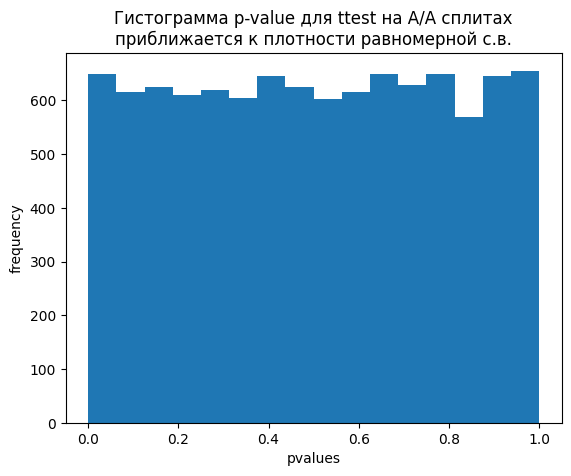

FPR / Наблюдаемая О1Р равна: 5.15%


In [ ]:
# посмотрим на искусственные «сплиты»
simulation_count = 10_000
sample_size = 1_000

pvalues = []

# Генерируем новые выборки на каждой итерации,
# так же сплит система будет каждый раз делить заново пользователей
# (но чтобы ускорить на практике A/A тестов используют бутстрап)
for _ in tqdm(range(simulation_count)):
    control_sample =   np.random.exponential(scale=1 / 0.001, size=sample_size)
    treatment_sample = np.random.exponential(scale=1 / 0.001, size=sample_size)

    pvalues.append(stats.ttest_ind(control_sample, treatment_sample, equal_var=False).pvalue)

plt.hist(pvalues, bins=16)
plt.xlabel("pvalues")
plt.ylabel("frequency")
plt.title(
    "Гистограмма p-value для ttest на A/A сплитах\n"
    + "приближается к плотности равномерной с.в."
)
plt.show()

print(f"FPR / Наблюдаемая О1Р равна: {np.mean(np.array(pvalues) < 0.05) * 100:.2f}%")

Q: Можно ли тут использовать z-test?

<img src="https://miro.medium.com/1*kwN_Y8GNf2ZB6sNQxngVyw@2x.jpeg" width="400">

A: Да, если `sample_size` достаточно большое. Больше 1000 точно пойдёт

  0%|          | 0/10000 [00:00<?, ?it/s]

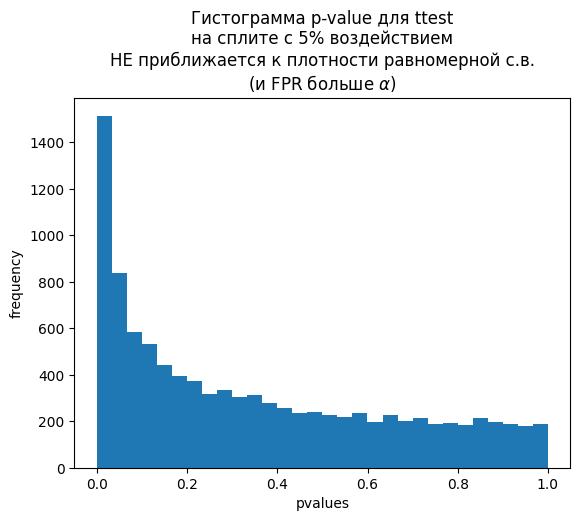

FPR / Наблюдаемая O1Р равна: 19.65%


In [ ]:
pvalues = []

# Сделаем выборки заведомо отличающимися
for _ in tqdm(range(simulation_count)):
    control_sample =   np.random.exponential(scale=1 / 0.001, size=sample_size)
    treatment_sample = np.random.exponential(scale=1 / 0.001, size=sample_size) * 1.05

    pvalues.append(stats.ttest_ind(control_sample, treatment_sample, equal_var=False).pvalue)

plt.hist(pvalues, bins=30)
plt.xlabel("pvalues")
plt.ylabel("frequency")
plt.title(
    "Гистограмма p-value для ttest\n"
    + "на сплите с 5% воздействием\n"
    + "НЕ приближается к плотности равномерной с.в.\n"
    + r"(и FPR больше $\alpha$)"
)
plt.show()

# Проверяем, что количество ложноположительных случаев не превышает альфа
print(f"FPR / Наблюдаемая O1Р равна: {np.mean(np.array(pvalues) < 0.05) * 100:.2f}%")

In [ ]:
# напишем сплит систему
def ab_split(id, salt):
    """
    Returns 't' (test) или 'c' (control) с 50/50 вероятностью.
    """

    test_id = str(id) + "-" + str(salt)
    test_id_digest = hashlib.md5(test_id.encode("ascii")).hexdigest()

    # Берём последний символ хеша и проверяем чётность
    if int(test_id_digest[-1], 16) % 2 == 0:
        return 't'
    else:
        return 'c'

In [ ]:
# прогоним на реальных данных
url = "https://raw.githubusercontent.com/polozkovdmitry/pda_dataset/refs/heads/main/2026_spring/sem_7_ab/sessions_full.csv"

df = pd.read_csv(url)
df["session_start_dttm"] = pd.to_datetime(df["session_start_dttm"], errors="raise")

print('первые 5:\n', df.head(5))
print('-'*10)
print('случайные 5:\n', df.sample(5))
print('-'*10)
print('последние 5:\n', df.tail(5))

/tmp/ipykernel_20328/837447565.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


первые 5:
    user_id  session_start_dttm treatment_high_contrast_flag  desktop_flag  satisfaction_metric  session_duration_min  purchase_flag  purchase_amount_rub rfm_category      registered_dttm  male_flag  moscow_flag  age first_name last_name  middle_name
0    75037 2023-05-30 01:48:26                          NaN             0                  NaN                     7              0                    0          NaN  2023-05-30 01:48:26          0            0   27    Tatiana   Morozov  89854735331
1    86321 2023-05-30 03:15:26                          NaN             0                  NaN                     4              1                  339          NaN  2023-05-30 03:15:26          1            0   30       Ilya    Volkov  89853583401
2    45165 2023-05-30 03:30:09                          NaN             1                  NaN                     5              0                    0          NaN  2023-05-30 03:30:09          1            0   26     Andrey    Pavlov  8

In [ ]:
# XXX - название вашего эксперимента
df["treatment_XXX_flag"] = df.user_id.apply(lambda user_id: ab_split(user_id, "SALT1"))
print('Вот так работает сплит система:\n', df["treatment_XXX_flag"].sample(5))

Вот так работает сплит система:
 152624    t
26645     c
13067     c
158304    c
174085    c
Name: treatment_XXX_flag, dtype: object


Q: Какой следующий шаг?

A: Строим распределение p-value для 1/ разных метрик, 2/ разных тестов, 3/ прочих встречающихся кейсах

## 2. Тест функционала высокой контрастности

In [ ]:
# тест начался 1 января 2026 в 00:00
start_dt = pd.to_datetime('2026-01-01')

df_pre_ab = df[
    df['session_start_dttm'] < start_dt
]

# гипотеза - Высокая контрастность позволяет лучше «увидеть» нужные кнопки
# => вероятность совершения покупки возрастает

# метрика - конверсия из сессии в покупку

Q: Для какой аудитории актуально?

<img src="https://miro.medium.com/1*kwN_Y8GNf2ZB6sNQxngVyw@2x.jpeg" width="400">

A: Потенциально на всех, а можно только на телефоны - кажется, что на компьютерах контрастность не так сильно влияет

In [ ]:
df_pre_ab_target_group = df_pre_ab[
    df_pre_ab['desktop_flag'] == 0
]

df_pre_ab_target_group_6m = df_pre_ab_target_group[
    df_pre_ab_target_group['session_start_dttm'] >= '2025-07-01'
]

print("среднее значение метрики до теста:", round(df_pre_ab_target_group['purchase_flag'].mean(), 3))

среднее значение метрики до теста: 0.326


A: как посчитать размер выборки?


Q: [Калькуляторы](https://mindbox.ru/tools/ab-test-calculator/) или внутренняя эвристика

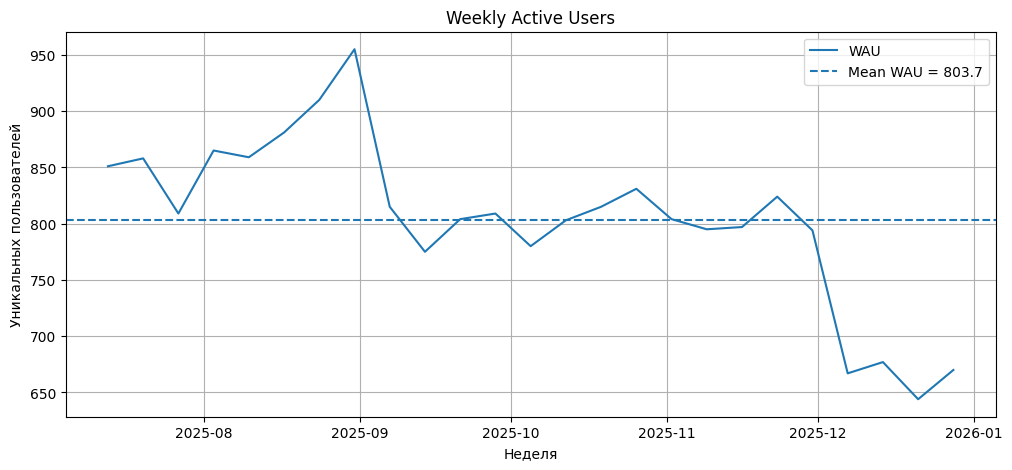

In [ ]:
df_plot = df_pre_ab_target_group_6m.copy()

weekly = (
    df_plot.set_index("session_start_dttm")
        .resample("W")["user_id"]
        .nunique()
)
# берём только полные недели
weekly = weekly[1:-1]

weekly_mean = weekly.mean()

plt.figure(figsize=(12, 5))
plt.plot(weekly.index, weekly.values, label="WAU")
plt.axhline(weekly_mean, linestyle="--", label=f"Mean WAU = {weekly_mean:.1f}")

plt.title("Weekly Active Users")
plt.xlabel("Неделя")
plt.ylabel("Уникальных пользователей")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
wau = 800                    # по истории
dimension_perc = 1/2         # нашему эксперименту доступно 50% целевого потока (его пространство)
sample_size_target = 3700    # с сайта-калькулятора

num_weeks = int(sample_size_target // (wau * dimension_perc) + 1)
num_weeks

10

In [ ]:
# start_dt задали выше
end_dt = start_dt + timedelta(weeks=num_weeks)


df_ab = df[
    (df['session_start_dttm'] >= start_dt)
    & (df['session_start_dttm'] < end_dt)
    & (df['treatment_high_contrast_flag'].notna()) # нужное пространство
]

In [ ]:

# ====== КОНФИГУРАЦИЯ ======
target_uplift = 0.05
confidence_level = 0.95

# ====== ДАННЫЕ ======
df_sorted = df_ab.sort_values('session_start_dttm').reset_index(drop=True)

time_points, deltas, ci_lower, ci_upper = [], [], [], []

for idx in range(1, len(df_sorted) + 1):
    chunk = df_sorted.iloc[:idx]
    c = chunk[chunk['treatment_high_contrast_flag'] == 'c']['purchase_flag']
    t = chunk[chunk['treatment_high_contrast_flag'] == 't']['purchase_flag']

    if len(c) == 0 or len(t) == 0:
        continue

    delta = t.mean() - c.mean()
    se = np.sqrt(t.mean() * (1 - t.mean()) / len(t) + c.mean() * (1 - c.mean()) / len(c))
    z = stats.norm.ppf((1 + confidence_level) / 2)

    time_points.append(idx)
    deltas.append(delta)
    ci_lower.append(delta - z * se)
    ci_upper.append(delta + z * se)

# ====== Z-ТЕСТ ======
c_final = df_ab[df_ab['treatment_high_contrast_flag'] == 'c']['purchase_flag']
t_final = df_ab[df_ab['treatment_high_contrast_flag'] == 't']['purchase_flag']

delta_final = t_final.mean() - c_final.mean()
se_final = np.sqrt(t_final.mean() * (1 - t_final.mean()) / len(t_final) +
                   c_final.mean() * (1 - c_final.mean()) / len(c_final))
z_stat = delta_final / se_final
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

# ====== ГРАФИК ======
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=time_points + time_points[::-1],
    y=ci_upper + ci_lower[::-1],
    fill='toself', fillcolor='rgba(46,134,171,0.15)',
    line=dict(color='rgba(0,0,0,0)'),
    name='95% ДИ'
))

fig.add_trace(go.Scatter(
    x=time_points, y=deltas,
    line=dict(color='#2E86AB', width=2),
    mode='lines', name='Δ'
))

fig.add_hline(y=target_uplift, line=dict(color='#A23B72', dash='dash', width=2),
              annotation_text=f'Цель {target_uplift:.0%}', annotation_position='top right')

fig.add_hline(y=0, line=dict(color='gray', dash='dot', width=1))

significance = '✓ Значимо' if p_value < 0.05 else 'Незначимо'
fig.update_layout(
    title=f'A/B тест: динамика Δ конверсии | p = {p_value:.4f} | {significance}',
    xaxis_title='Накопленные наблюдения',
    yaxis_title='Аплифт метрики конверсии',
    yaxis_tickformat='.1%',
    legend=dict(orientation='h', y=1.08),
    template='plotly_white',
    height=500
)

fig.show()

# ====== ПРОВЕРКА ГИПОТЕЗЫ ======
print(f'Z-статистика : {z_stat:.4f}')
print(f'P-значение   : {p_value:.4f}')
print()
if p_value < 0.05:
    print(f'Вывод: отвергаем H₀ — разница между группами статистически значима.')
    print(f'Аплифт составил {delta_final:.2%} при целевом значении {target_uplift:.0%}.')
else:
    print(f'Вывод: не удаётся отвергнуть H₀ — разница между группами незначима.')
    print(f'Наблюдаемый аплифт {delta_final:.2%} недостаточен для уверенного вывода.')

Z-статистика : 2.7151
P-значение   : 0.0066

Вывод: отвергаем H₀ — разница между группами статистически значима.
Аплифт составил 3.77% при целевом значении 5%.


Q: А как проверить контра-метрику?

<img src="https://miro.medium.com/1*kwN_Y8GNf2ZB6sNQxngVyw@2x.jpeg" width="400">

A: На практике на глаз, но по хорошему надо запутить такой соответствующий тест (на том же сплите)

In [ ]:
# ====== КОНФИГУРАЦИЯ ======
contra_metric_column = 'session_duration_min'

# ====== ДАННЫЕ ======
df_sorted = df_ab.sort_values('session_start_dttm').reset_index(drop=True)

time_points, mean_c, mean_t = [], [], []

for idx in range(1, len(df_sorted) + 1):
    chunk = df_sorted.iloc[:idx]
    c = chunk[chunk['treatment_high_contrast_flag'] == 'c'][contra_metric_column]
    t = chunk[chunk['treatment_high_contrast_flag'] == 't'][contra_metric_column]

    if len(c) == 0 or len(t) == 0:
        continue

    time_points.append(idx)
    mean_c.append(c.mean())
    mean_t.append(t.mean())

# ====== ГРАФИК ======
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=time_points, y=mean_c,
    line=dict(color='#2E86AB', width=2),
    mode='lines', name='Контроль (c)'
))

fig.add_trace(go.Scatter(
    x=time_points, y=mean_t,
    line=dict(color='#A23B72', width=2),
    mode='lines', name='Тест (t)'
))

fig.update_layout(
    title='A/B тест: средняя длительность сессии по группам',
    xaxis_title='Накопленные наблюдения',
    yaxis_title='Длительность сессии (мин)',
    legend=dict(orientation='h', y=1.08),
    template='plotly_white',
    height=500
)

fig.show()

Q: Как принять решение по выкатке в прод?

A: только экспертно, взвешивая за и против такого роста метрик